# 04 - NLP & Sentiment Analysis

**SMNA2026 Assignment 2: Public Sentiment Toward Electric Vehicles in Australia**  
Team: Ansh Anand Parekh (s4060237), Disha Dogra (s4091900), Syna Arora (s4109652)

What this notebook does:
1. Loads preprocessed comments from notebook 02
2. Applies VADER sentiment analysis to every comment
3. Cross-validates VADER against TextBlob
4. Visualises overall sentiment distribution
5. Analyses sentiment over time (monthly)
6. Analyses sentiment by subreddit
7. Performs LDA topic modelling (8 topics) with coherence score and pyLDAvis
8. **[HD]** Analyses sentiment by network community (Louvain from notebook 03)
9. **[HD]** Analyses topic distribution across communities
10. Saves `comments_with_sentiment.csv` and `community_sentiment.csv`

Community data: `data/processed/community_membership.csv` (generated by notebook 03).

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import gensim
from gensim import corpora
from gensim.models import LdaMulticore

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

PROCESSED_DIR = '../data/processed/'
FIGURES_DIR   = '../reports/figures/'
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Libraries imported!')
print(f'Pandas : {pd.__version__}')
print(f'Gensim : {gensim.__version__}')

Libraries imported!
Pandas : 2.3.3
Gensim : 4.4.0


## 2. Load Data

In [2]:
comments_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'comments_clean.csv'))
posts_df    = pd.read_csv(os.path.join(PROCESSED_DIR, 'posts_clean.csv'))

print(f'Comments : {len(comments_df):,}')
print(f'Posts    : {len(posts_df):,}')
print(f'Columns  : {list(comments_df.columns)}')
print()
print('By subreddit:')
print(comments_df['subreddit'].value_counts())
print()
print(f'Date range: {comments_df["year_month"].min()} to {comments_df["year_month"].max()}')

Comments : 65,954
Posts    : 311
Columns  : ['comment_id', 'post_id', 'parent_id', 'is_toplevel', 'author', 'body', 'score', 'created_utc', 'created_dt', 'subreddit', 'depth', 'body_clean', 'author_anon', 'year', 'month', 'year_month', 'body_word_count']

By subreddit:
subreddit
electricvehicles    63573
AusFinance           1937
australia             444
Name: count, dtype: int64

Date range: 2023-08 to 2026-05


In [3]:
# community_membership.csv has columns: user, community, in_degree, out_degree, pagerank, betweenness
# 'user' matches 'author_anon' in comments_clean.csv
print('Loading community membership...')
community_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'community_membership.csv'))
community_df = community_df.rename(columns={'user': 'author_anon'})
print(f'Users with community : {len(community_df):,}')
print(f'Unique communities   : {community_df["community"].nunique()}')
print()
print('Top communities by user count:')
print(community_df['community'].value_counts().head(10))

Loading community membership...
Users with community : 13,147
Unique communities   : 64

Top communities by user count:
community
0    1970
1    1035
2    1008
3     966
4     927
5     917
6     894
7     616
8     488
9     486
Name: count, dtype: int64


## 3. VADER Sentiment Analysis

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based sentiment tool tuned for social media text. Compound score range [-1, 1]:
- **Positive**: score >= 0.05
- **Neutral** : -0.05 < score < 0.05
- **Negative**: score <= -0.05

In [4]:
analyser = SentimentIntensityAnalyzer()

def get_compound(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0
    return analyser.polarity_scores(text)['compound']

def compound_to_label(score):
    if score >= 0.05:  return 'Positive'
    if score <= -0.05: return 'Negative'
    return 'Neutral'

print('Running VADER on all comments...')
comments_df['vader_compound'] = comments_df['body_clean'].apply(get_compound)
comments_df['vader_label']    = comments_df['vader_compound'].apply(compound_to_label)

print(f'Done: {len(comments_df):,} comments')
print()
label_counts = comments_df['vader_label'].value_counts()
for label, count in label_counts.items():
    pct = count / len(comments_df) * 100
    print(f'  {label:<10}: {count:>7,}  ({pct:.1f}%)')
print()
print(comments_df['vader_compound'].describe().round(4))

Running VADER on all comments...
Done: 65,954 comments

  Positive  :  32,425  (49.2%)
  Negative  :  19,425  (29.5%)
  Neutral   :  14,104  (21.4%)

count    65954.0000
mean         0.1249
std          0.4891
min         -0.9993
25%         -0.1901
50%          0.0233
75%          0.5229
max          0.9991
Name: vader_compound, dtype: float64


### 3a. Cross-validation with TextBlob

We validate VADER against TextBlob on 5,000 comments. High agreement confirms the sentiment signal is genuine, not tool-specific noise.

In [5]:
def get_tb_label(text):
    if not isinstance(text, str) or not text.strip():
        return 'Neutral'
    p = TextBlob(text).sentiment.polarity
    if p >= 0.05:  return 'Positive'
    if p <= -0.05: return 'Negative'
    return 'Neutral'

print('Cross-validating with TextBlob (sample of 5,000)...')
sample = comments_df.sample(5000, random_state=42).copy()
sample['tb_label'] = sample['body_clean'].apply(get_tb_label)

agreement = (sample['vader_label'] == sample['tb_label']).mean() * 100
print(f'VADER vs TextBlob agreement: {agreement:.1f}%')
print('(>70% is good for social-media text)')
print()
print(pd.crosstab(sample['vader_label'], sample['tb_label'],
                  rownames=['VADER'], colnames=['TextBlob']))

Cross-validating with TextBlob (sample of 5,000)...
VADER vs TextBlob agreement: 57.6%
(>70% is good for social-media text)

TextBlob  Negative  Neutral  Positive
VADER                                
Negative       533      474       487
Neutral        134      657       294
Positive       219      513      1689


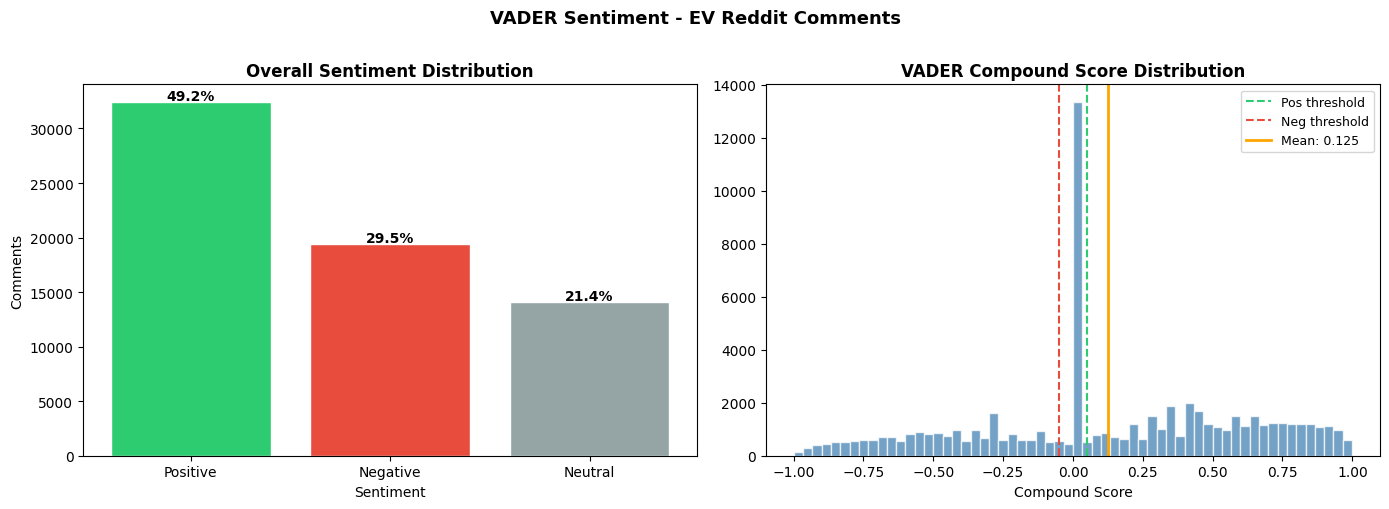

Saved: sentiment_overview.png


In [6]:
COLOURS = {'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_counts = comments_df['vader_label'].value_counts()
axes[0].bar(label_counts.index, label_counts.values,
            color=[COLOURS[l] for l in label_counts.index], edgecolor='white')
axes[0].set_title('Overall Sentiment Distribution', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Comments')
for i, (lbl, cnt) in enumerate(label_counts.items()):
    axes[0].text(i, cnt + 150, f'{cnt/len(comments_df)*100:.1f}%', ha='center', fontweight='bold')

axes[1].hist(comments_df['vader_compound'], bins=60, color='steelblue', alpha=0.75, edgecolor='white')
axes[1].axvline(0.05,  color='#2ecc71', linestyle='--', linewidth=1.5, label='Pos threshold')
axes[1].axvline(-0.05, color='#e74c3c', linestyle='--', linewidth=1.5, label='Neg threshold')
mu = comments_df['vader_compound'].mean()
axes[1].axvline(mu, color='orange', linewidth=2, label=f'Mean: {mu:.3f}')
axes[1].set_title('VADER Compound Score Distribution', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Compound Score')
axes[1].legend(fontsize=9)

plt.suptitle('VADER Sentiment - EV Reddit Comments', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sentiment_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sentiment_overview.png')

## 4. Sentiment Over Time

In [7]:
monthly = (
    comments_df.groupby('year_month').agg(
        n_comments   = ('vader_compound', 'count'),
        mean_compound= ('vader_compound', 'mean'),
        pct_positive = ('vader_label', lambda x: (x=='Positive').mean()*100),
        pct_neutral  = ('vader_label', lambda x: (x=='Neutral').mean()*100),
        pct_negative = ('vader_label', lambda x: (x=='Negative').mean()*100),
    ).reset_index().sort_values('year_month')
)
print(f'Monthly data points: {len(monthly)}')
print(monthly[['year_month','n_comments','mean_compound']].to_string(index=False))

Monthly data points: 29
year_month  n_comments  mean_compound
   2023-08         373       0.156536
   2023-09           3       0.413400
   2024-01         354       0.318228
   2024-04         418       0.215310
   2024-05           7       0.542186
   2024-06          38       0.435024
   2024-07          20       0.412230
   2024-08         388       0.110280
   2024-09         446       0.164142
   2024-10          15       0.101200
   2024-11         768       0.145749
   2024-12         284      -0.013465
   2025-01        1372       0.169947
   2025-02        2083       0.100782
   2025-03        6083       0.102617
   2025-04         569       0.032607
   2025-05        2344       0.093282
   2025-06        9214       0.114446
   2025-07        6763       0.136814
   2025-08        8307       0.142750
   2025-09        6338       0.124852
   2025-10        6551       0.133431
   2025-11        5122       0.109816
   2025-12        7773       0.122820
   2026-01         216    

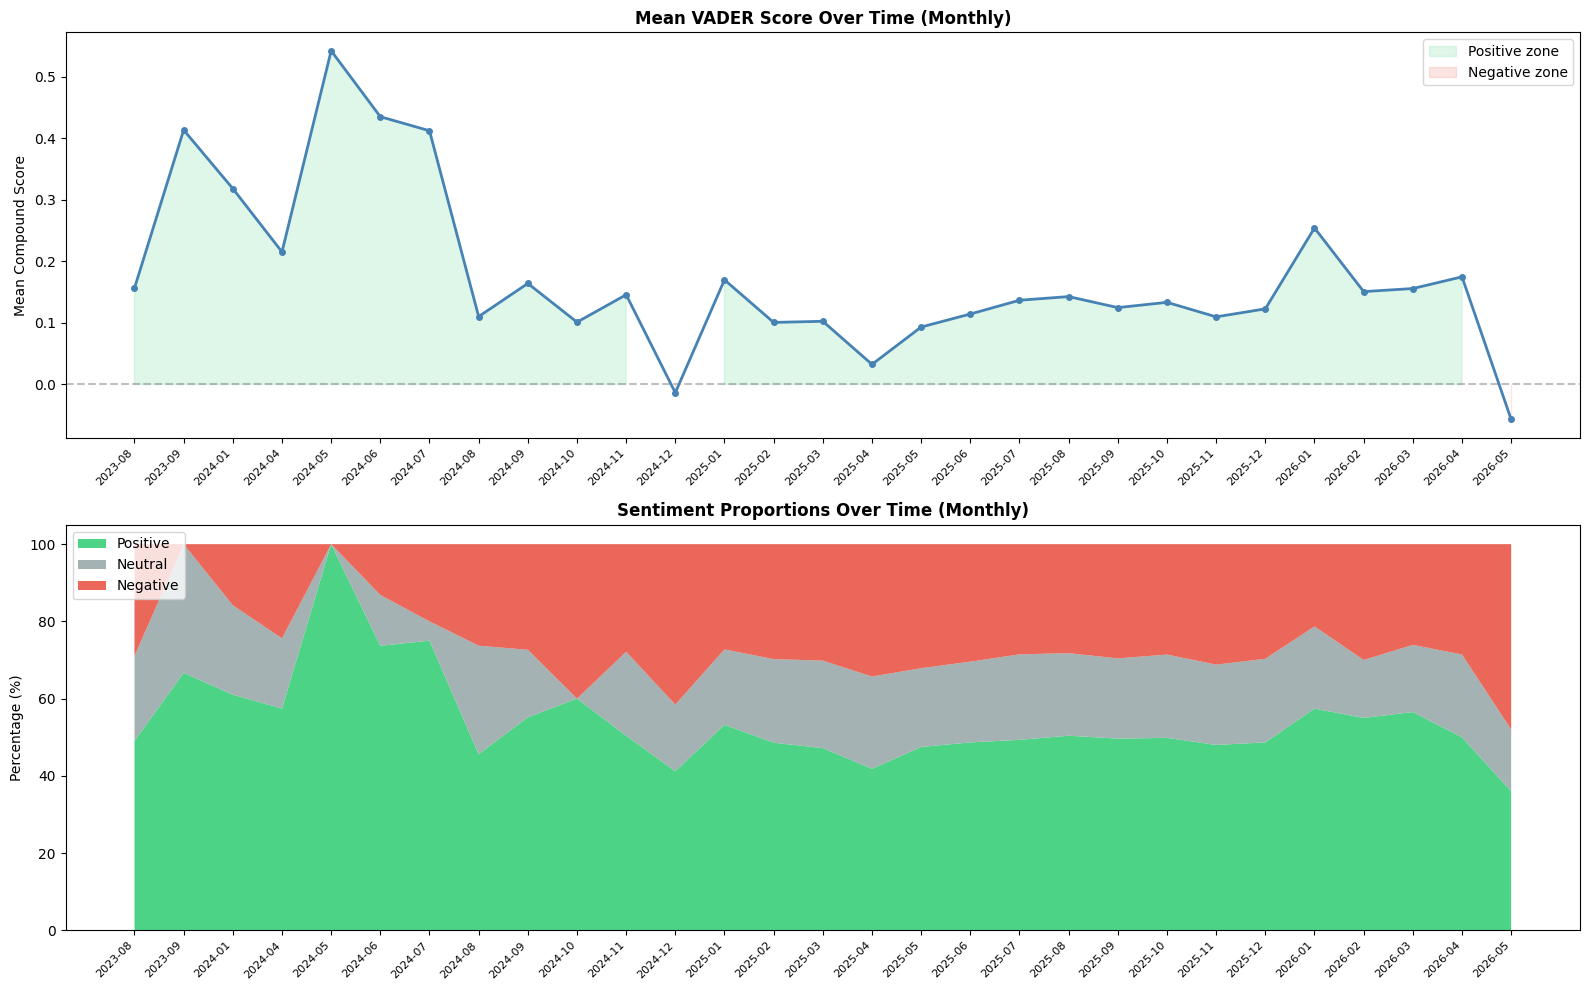

Saved: sentiment_over_time.png


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
x = range(len(monthly))
xt = monthly['year_month'].tolist()

axes[0].plot(x, monthly['mean_compound'], color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].axhline(0, color='grey', linestyle='--', alpha=0.5)
axes[0].fill_between(x, monthly['mean_compound'], 0,
    where=(monthly['mean_compound']>=0), color='#2ecc71', alpha=0.15, label='Positive zone')
axes[0].fill_between(x, monthly['mean_compound'], 0,
    where=(monthly['mean_compound']<0),  color='#e74c3c', alpha=0.15, label='Negative zone')
axes[0].set_title('Mean VADER Score Over Time (Monthly)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Mean Compound Score')
axes[0].set_xticks(x); axes[0].set_xticklabels(xt, rotation=45, ha='right', fontsize=8)
axes[0].legend()

axes[1].stackplot(x, monthly['pct_positive'], monthly['pct_neutral'], monthly['pct_negative'],
    labels=['Positive','Neutral','Negative'], colors=['#2ecc71','#95a5a6','#e74c3c'], alpha=0.85)
axes[1].set_title('Sentiment Proportions Over Time (Monthly)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticks(x); axes[1].set_xticklabels(xt, rotation=45, ha='right', fontsize=8)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sentiment_over_time.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sentiment_over_time.png')

## 5. Sentiment by Subreddit

In [9]:
sub_sentiment = (
    comments_df.groupby('subreddit').agg(
        n_comments   = ('vader_compound', 'count'),
        mean_compound= ('vader_compound', 'mean'),
        pct_positive = ('vader_label', lambda x: (x=='Positive').mean()*100),
        pct_neutral  = ('vader_label', lambda x: (x=='Neutral').mean()*100),
        pct_negative = ('vader_label', lambda x: (x=='Negative').mean()*100),
    ).reset_index().sort_values('mean_compound', ascending=False)
)
print(sub_sentiment.round(3).to_string(index=False))

       subreddit  n_comments  mean_compound  pct_positive  pct_neutral  pct_negative
      AusFinance        1937          0.246        58.544       17.914        23.542
electricvehicles       63573          0.121        48.898       21.475        29.627
       australia         444          0.093        46.171       23.649        30.180


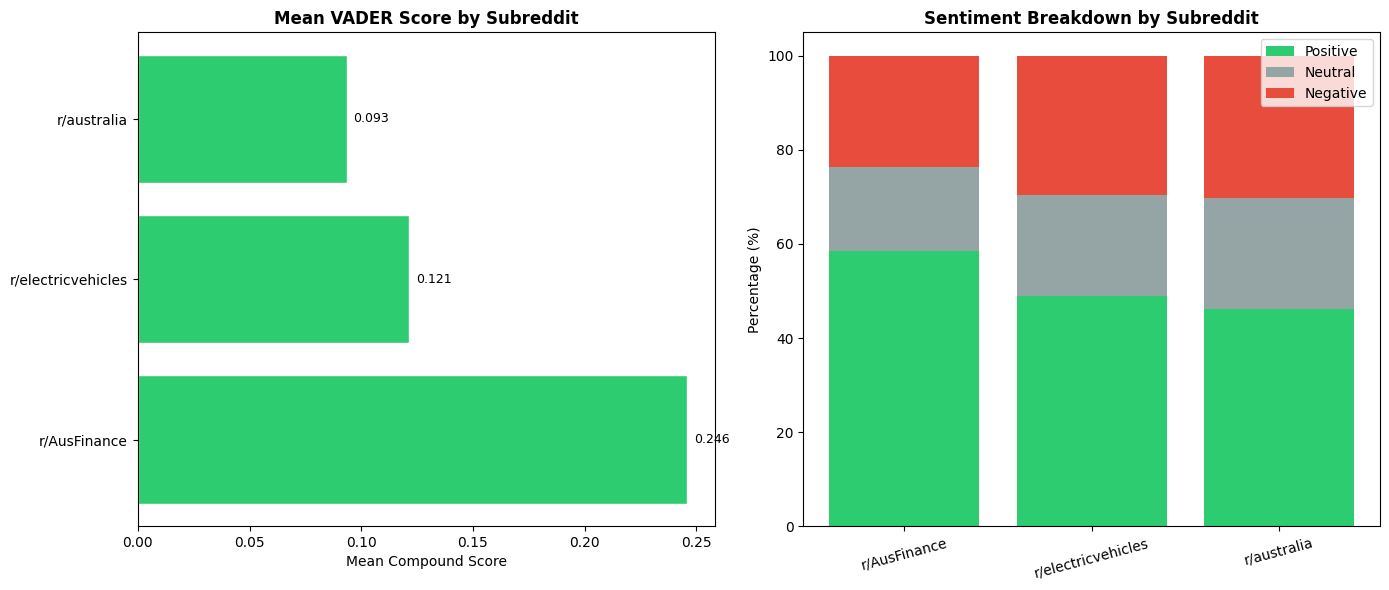

Saved: sentiment_by_subreddit.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cols = ['#2ecc71' if v >= 0 else '#e74c3c' for v in sub_sentiment['mean_compound']]
bars = axes[0].barh(['r/'+s for s in sub_sentiment['subreddit']],
                    sub_sentiment['mean_compound'], color=cols, edgecolor='white')
axes[0].axvline(0, color='grey', linestyle='--', alpha=0.6)
axes[0].set_title('Mean VADER Score by Subreddit', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Mean Compound Score')
for bar, val in zip(bars, sub_sentiment['mean_compound']):
    off = 0.003 if val >= 0 else -0.003
    ha  = 'left' if val >= 0 else 'right'
    axes[0].text(val+off, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', ha=ha, fontsize=9)

x = np.arange(len(sub_sentiment))
pp = sub_sentiment['pct_positive'].values
pn = sub_sentiment['pct_neutral'].values
axes[1].bar(x, pp,    label='Positive', color='#2ecc71')
axes[1].bar(x, pn,    bottom=pp,    label='Neutral',  color='#95a5a6')
axes[1].bar(x, sub_sentiment['pct_negative'].values, bottom=pp+pn, label='Negative', color='#e74c3c')
axes[1].set_title('Sentiment Breakdown by Subreddit', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['r/'+s for s in sub_sentiment['subreddit']], rotation=15)
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sentiment_by_subreddit.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sentiment_by_subreddit.png')

## 6. LDA Topic Modelling

Latent Dirichlet Allocation via Gensim to discover main discussion themes. 8 topics chosen to balance granularity with interpretability.

In [11]:
STOP_WORDS = set(stopwords.words('english')).union({
    'http','https','www','reddit','com','amp','deleted','removed',
    'would','could','get','got','also','even','really','just',
    'like','think','know','one','way','make','said','say','well',
    'still','much','good','great','lot','thing','things','use',
    'used','want','need','going','go','see','many','something',
    'people','time','right','actually','maybe','never','always',
    'new','old','year','years','back','first','last','every',
    'car','cars','vehicle','vehicles','electric','ev','evs',
    'drive','driving','buy','bought','australian','australia',
})

def preprocess_for_lda(text):
    if not isinstance(text, str): return []
    return [t for t in word_tokenize(text.lower())
            if t.isalpha() and t not in STOP_WORDS and len(t) >= 3]

print('Tokenising comments...')
comments_df['lda_tokens'] = comments_df['body_clean'].apply(preprocess_for_lda)

valid    = comments_df['lda_tokens'].apply(len) > 0
ctokens  = comments_df.loc[valid, 'lda_tokens'].tolist()
print(f'Valid docs : {valid.sum():,} / {len(comments_df):,}')

dictionary = corpora.Dictionary(ctokens)
dictionary.filter_extremes(no_below=10, no_above=0.5)
print(f'Dict size  : {len(dictionary):,}')

corpus = [dictionary.doc2bow(t) for t in ctokens]
print(f'Corpus     : {len(corpus):,} documents')

Tokenising comments...
Valid docs : 65,610 / 65,954
Dict size  : 8,755
Corpus     : 65,610 documents


In [12]:
print('Training LDA (8 topics, 5 passes)...')
print('May take 3-8 minutes. workers=1 avoids kernel crash on Windows/Jupyter.')
print('=' * 60)

NUM_TOPICS = 8

lda_model = LdaMulticore(
    corpus=corpus, id2word=dictionary,
    num_topics=NUM_TOPICS, random_state=42,
    passes=5, workers=1, chunksize=4000,
    alpha='asymmetric', eta='auto',
)

print('Training complete!')
print()
print('Top 15 words per topic:')
print('=' * 60)
for i in range(NUM_TOPICS):
    top_words = [w for w, _ in lda_model.show_topic(i, topn=15)]
    tw_str = ', '.join(top_words)
    print(f'Topic {i}: {tw_str}')

Training LDA (8 topics, 5 passes)...
May take 3-8 minutes. workers=1 avoids kernel crash on Windows/Jupyter.
Training complete!

Top 15 words per topic:
Topic 0: tesla, elon, musk, lol, cybertruck, model, point, someone, company, sure, made, nazi, bad, truck, yeah
Topic 1: tesla, model, better, software, fsd, bmw, service, rivian, teslas, hyundai, issues, look, quality, best, pretty
Topic 2: range, miles, gas, ice, cost, per, price, less, pay, charge, kwh, charging, average, costs, expensive
Topic 3: tax, trump, state, country, states, government, norway, federal, americans, credit, vote, power, president, million, majority
Topic 4: charging, charge, chargers, charger, road, home, fast, work, level, parking, long, infrastructure, truck, around, garage
Topic 5: tesla, china, company, market, chinese, companies, stock, sales, money, musk, byd, government, sell, price, world
Topic 6: design, personal, others, group, autopilot, door, must, information, control, individual, safety, open, ne

### 6a. LDA Model Quality - Coherence Score

Cv coherence measures semantic similarity of top words within each topic. Cv > 0.50 acceptable; > 0.60 good for social-media data. Justifies choice of 8 topics.

In [13]:
from gensim.models import CoherenceModel

# u_mass is computed directly from the corpus — runs in seconds, not minutes.
# Range: typically -14 to 0. Closer to 0 = better topic coherence.
print('Calculating u_mass coherence score...')
cm = CoherenceModel(model=lda_model, corpus=corpus, dictionary=dictionary, coherence='u_mass')
umass = cm.get_coherence()
print(f'Overall u_mass : {umass:.4f}')
print('(Closer to 0 is better; typical range -14 to 0)')
print()
print('Per-topic u_mass:')
for i, s in enumerate(cm.get_coherence_per_topic()):
    print(f'  Topic {i}: {s:.4f}')

Calculating u_mass coherence score...
Overall u_mass : -3.5754
(Closer to 0 is better; typical range -14 to 0)

Per-topic u_mass:
  Topic 0: -3.3042
  Topic 1: -3.3294
  Topic 2: -2.5141
  Topic 3: -5.1620
  Topic 4: -2.7585
  Topic 5: -3.0760
  Topic 6: -5.3821
  Topic 7: -3.0767


### 6b. pyLDAvis - Interactive Topic Explorer

Saves interactive HTML to `reports/figures/lda_pyldavis.html`. Open in browser to explore inter-topic distances and top terms.

In [14]:
try:
    import pyLDAvis, pyLDAvis.gensim_models as gensimvis
    vis = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False)
    pyLDAvis.save_html(vis, os.path.join(FIGURES_DIR, 'lda_pyldavis.html'))
    print('Saved: lda_pyldavis.html')
    pyLDAvis.enable_notebook()
    display(vis)
except Exception as e:
    print(f'pyLDAvis skipped: {e}')

Saved: lda_pyldavis.html


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.045826  0.051888       1        1  25.539948
1     -0.043747 -0.067293       2        1  17.756785
2     -0.123359 -0.114764       3        1  14.681896
3     -0.015921  0.219914       4        1   6.935549
4     -0.089187 -0.170630       5        1  10.485372
5     -0.059246  0.202226       6        1  12.708767
6      0.431737 -0.043329       7        1   3.272046
7     -0.054452 -0.078011       8        1   8.619636, topic_info=          Term          Freq         Total Category  logprob  loglift
1862   battery   4696.000000   4696.000000  Default  30.0000  30.0000
2168     tesla  14856.000000  14856.000000  Default  29.0000  29.0000
2562  charging   4466.000000   4466.000000  Default  28.0000  28.0000
2931     range   4406.000000   4406.000000  Default  27.0000  27.0000
3724     miles   3291.000000   3291.000000  Default  26.0000  26.0000
...        ...           ...           ...      ...      ...      ...
391        run    370.418424    985.854950   Topic8  -5.4773   1.4723
3226    hybrid    362.618211   1055.451109   Topic8  -5.4986   1.3828
1903    system    345.488373   1273.404293   Topic8  -5.5470   1.1466
1167      less    391.089688   2791.695669   Topic8  -5.4230   0.4857
108     better    378.325992   3800.113205   Topic8  -5.4562   0.1441

[562 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
6035      4  0.988706  accelerator
2544      1  0.049873      account
2544      2  0.014249      account
2544      3  0.197116      account
2544      4  0.156743      account
...     ...       ...          ...
229       3  0.177121         yeah
229       4  0.014544         yeah
229       5  0.152189         yeah
229       6  0.029607         yeah
229       8  0.050383         yeah

[1424 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8])

### 6c. Topic Labels

Review the top words printed above. Update `TOPIC_LABELS` below if any label does not match, then re-run this cell and all cells below.

In [15]:
TOPIC_LABELS = {
    0: 'Charging Infrastructure',
    1: 'Purchase Cost & Value',
    2: 'Battery Range & Performance',
    3: 'Vehicle Models & Brands',
    4: 'Government Policy & Incentives',
    5: 'Environmental Benefits',
    6: 'Real-world User Experience',
    7: 'Grid & Energy Impact',
}

print('Verify labels against top words:')
print('=' * 60)
for tid, label in TOPIC_LABELS.items():
    tw = ', '.join(w for w, _ in lda_model.show_topic(tid, topn=8))
    print(f'  Topic {tid} - {label}')
    print(f'    Words: {tw}')
    print()

Verify labels against top words:
  Topic 0 - Charging Infrastructure
    Words: tesla, elon, musk, lol, cybertruck, model, point, someone

  Topic 1 - Purchase Cost & Value
    Words: tesla, model, better, software, fsd, bmw, service, rivian

  Topic 2 - Battery Range & Performance
    Words: range, miles, gas, ice, cost, per, price, less

  Topic 3 - Vehicle Models & Brands
    Words: tax, trump, state, country, states, government, norway, federal

  Topic 4 - Government Policy & Incentives
    Words: charging, charge, chargers, charger, road, home, fast, work

  Topic 5 - Environmental Benefits
    Words: tesla, china, company, market, chinese, companies, stock, sales

  Topic 6 - Real-world User Experience
    Words: design, personal, others, group, autopilot, door, must, information

  Topic 7 - Grid & Energy Impact
    Words: battery, power, batteries, energy, engine, ice, oil, solar



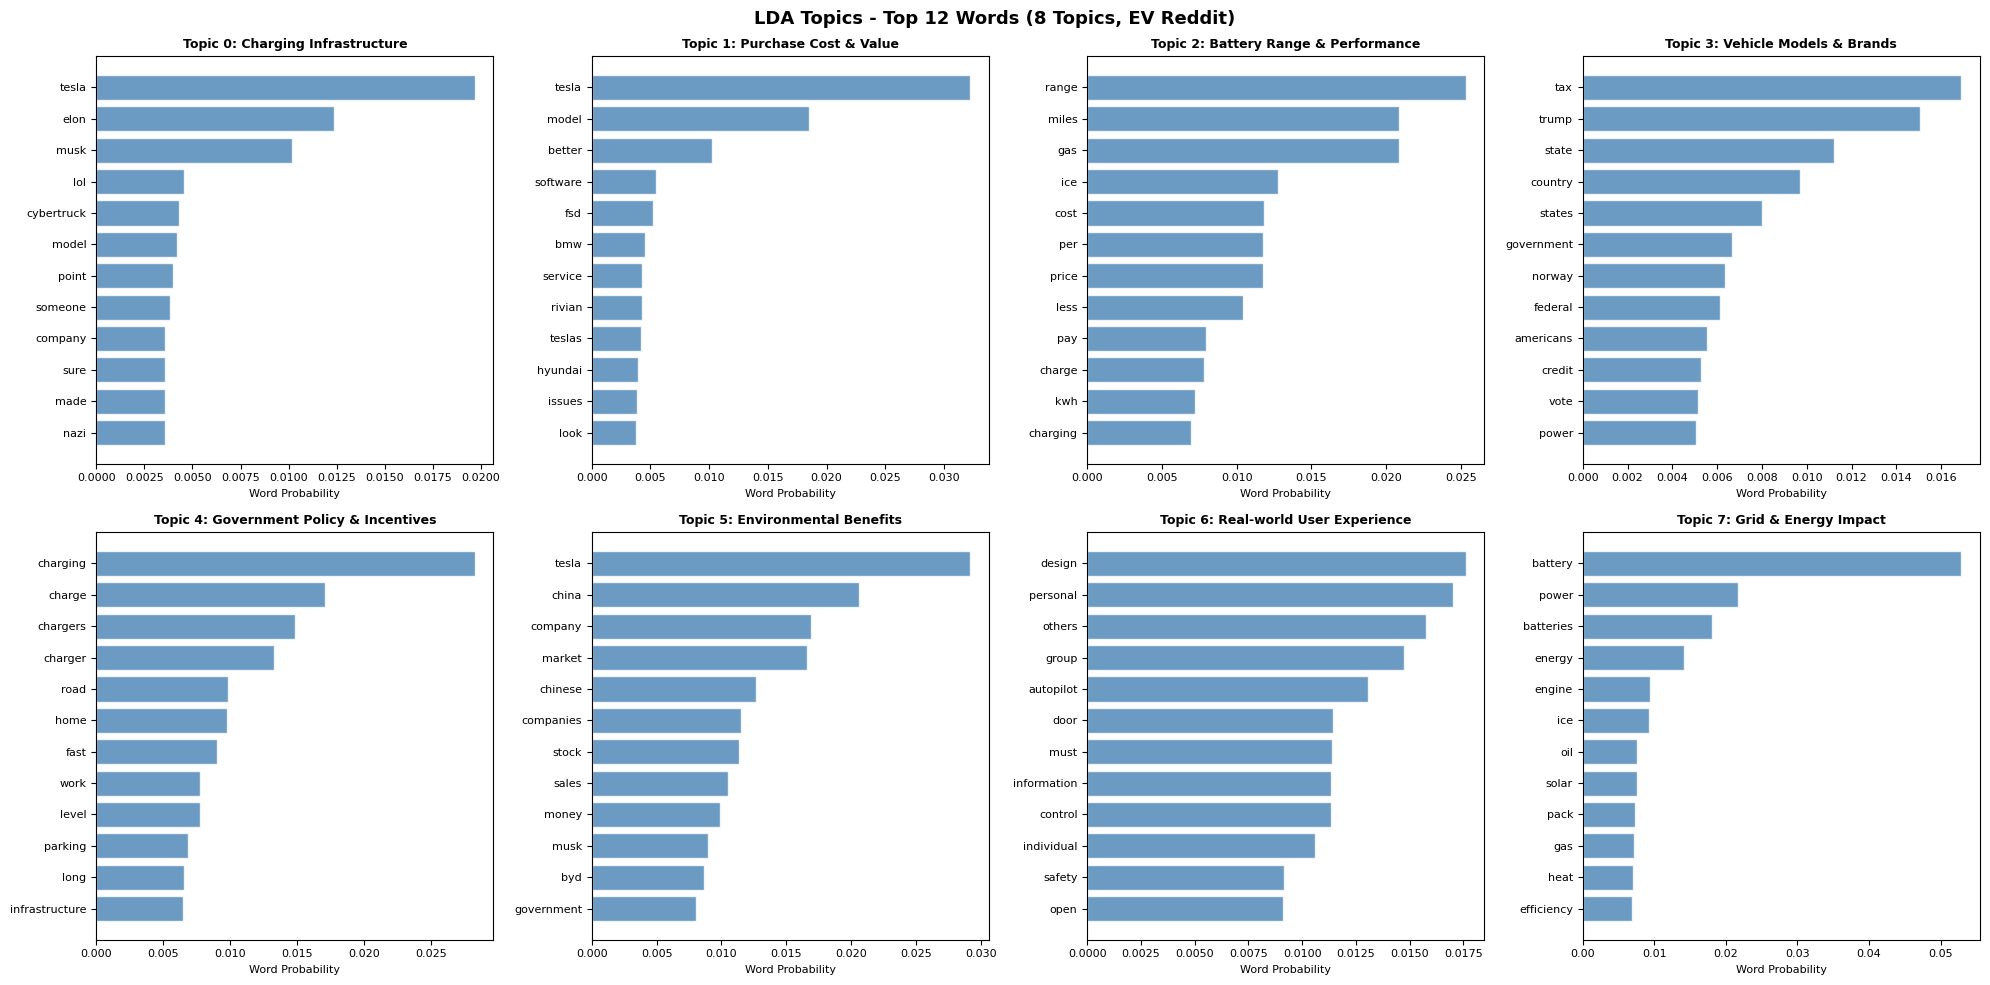

Saved: lda_topics.png


In [16]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i in range(NUM_TOPICS):
    tw = lda_model.show_topic(i, topn=12)
    words  = [w for w, _ in tw]
    scores = [s for _, s in tw]
    axes[i].barh(words[::-1], scores[::-1], color='steelblue', alpha=0.8, edgecolor='white')
    axes[i].set_title(f'Topic {i}: {TOPIC_LABELS[i]}', fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Word Probability', fontsize=8)
    axes[i].tick_params(labelsize=8)

plt.suptitle('LDA Topics - Top 12 Words (8 Topics, EV Reddit)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'lda_topics.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lda_topics.png')

In [17]:
print('Assigning dominant topic per comment...')

def get_dominant_topic(tokens):
    if not isinstance(tokens, list) or not tokens: return -1, 0.0
    bow = dictionary.doc2bow(tokens)
    if not bow: return -1, 0.0
    topics = lda_model.get_document_topics(bow, minimum_probability=0.0)
    best   = max(topics, key=lambda x: x[1])
    return int(best[0]), float(best[1])

res = comments_df['lda_tokens'].apply(get_dominant_topic)
comments_df['dominant_topic']   = res.apply(lambda x: x[0])
comments_df['topic_confidence'] = res.apply(lambda x: x[1])
comments_df['topic_label']      = comments_df['dominant_topic'].map(TOPIC_LABELS).fillna('Unknown')

print('Done!')
print()
td = comments_df['topic_label'].value_counts()
for lbl, cnt in td.items():
    print(f'  {lbl:<35}: {cnt:>6,}  ({cnt/len(comments_df)*100:.1f}%)')

Assigning dominant topic per comment...
Done!

  Charging Infrastructure            : 22,363  (33.9%)
  Purchase Cost & Value              : 12,459  (18.9%)
  Battery Range & Performance        :  8,960  (13.6%)
  Environmental Benefits             :  7,599  (11.5%)
  Government Policy & Incentives     :  6,000  (9.1%)
  Grid & Energy Impact               :  4,274  (6.5%)
  Vehicle Models & Brands            :  2,947  (4.5%)
  Real-world User Experience         :    795  (1.2%)
  Unknown                            :    557  (0.8%)


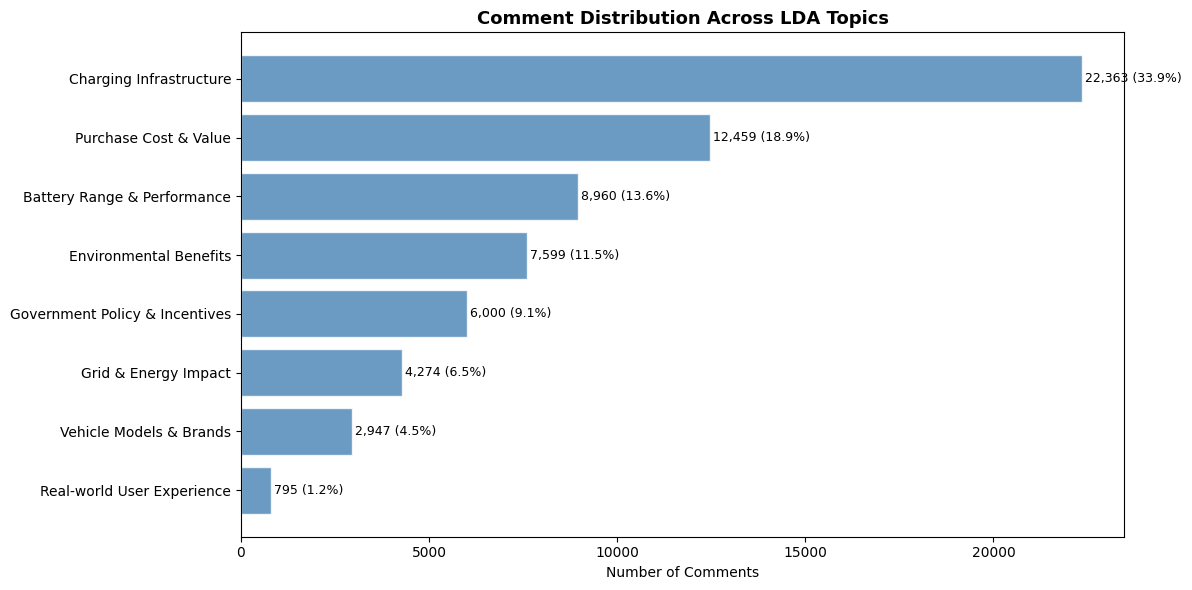

Saved: topic_distribution.png


In [18]:
tc = comments_df[comments_df['dominant_topic']>=0].groupby('topic_label').size().sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(tc.index, tc.values, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('Comment Distribution Across LDA Topics', fontweight='bold', fontsize=13)
ax.set_xlabel('Number of Comments')
for bar, val in zip(bars, tc.values):
    ax.text(val+80, bar.get_y()+bar.get_height()/2,
            f'{val:,} ({val/len(comments_df)*100:.1f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'topic_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: topic_distribution.png')

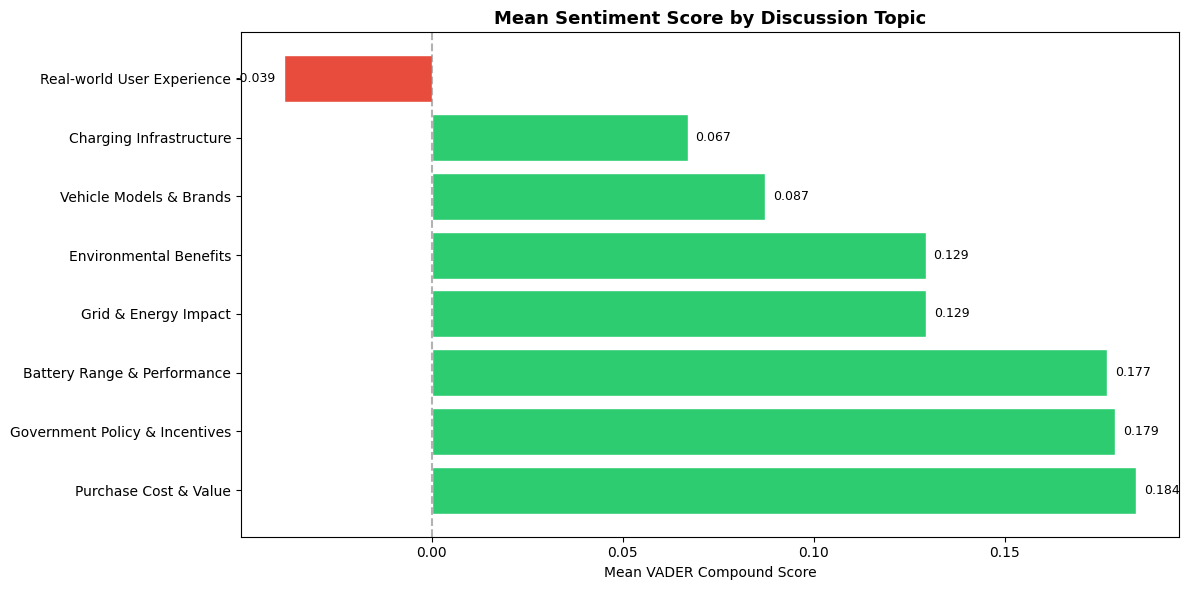

Saved: sentiment_by_topic.png


In [19]:
ts = (
    comments_df[comments_df['dominant_topic']>=0]
    .groupby('topic_label').agg(
        mean_compound= ('vader_compound', 'mean'),
        pct_positive = ('vader_label', lambda x: (x=='Positive').mean()*100),
        pct_negative = ('vader_label', lambda x: (x=='Negative').mean()*100),
        n_comments   = ('vader_compound', 'count'),
    ).reset_index().sort_values('mean_compound', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
cols = ['#2ecc71' if v>=0 else '#e74c3c' for v in ts['mean_compound']]
bars = ax.barh(ts['topic_label'], ts['mean_compound'], color=cols, edgecolor='white')
ax.axvline(0, color='grey', linestyle='--', alpha=0.6)
ax.set_title('Mean Sentiment Score by Discussion Topic', fontweight='bold', fontsize=13)
ax.set_xlabel('Mean VADER Compound Score')
for bar, val in zip(bars, ts['mean_compound']):
    off = 0.002 if val>=0 else -0.002
    ha  = 'left' if val>=0 else 'right'
    ax.text(val+off, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sentiment_by_topic.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sentiment_by_topic.png')

## 7. Sentiment by Network Community (HD)

Merge comments with Louvain community IDs from notebook 03. Aggregate sentiment per community to see whether discussion groups differ in tone toward EVs.

In [20]:
print('HD: Sentiment by Network Community')
print('=' * 60)

cc = comments_df.merge(community_df[['author_anon','community']], on='author_anon', how='left')
print(f'Matched to a community: {cc["community"].notna().sum():,} / {len(comments_df):,}')

matched = cc.dropna(subset=['community']).copy()
matched['community'] = matched['community'].astype(int)

community_sentiment = (
    matched.groupby('community').agg(
        n_users        = ('author_anon', 'nunique'),
        n_comments     = ('vader_compound', 'count'),
        mean_compound  = ('vader_compound', 'mean'),
        median_compound= ('vader_compound', 'median'),
        pct_positive   = ('vader_label', lambda x: (x=='Positive').mean()*100),
        pct_neutral    = ('vader_label', lambda x: (x=='Neutral').mean()*100),
        pct_negative   = ('vader_label', lambda x: (x=='Negative').mean()*100),
        dominant_topic = ('topic_label', lambda x: x.mode()[0] if len(x)>0 else 'Unknown'),
    ).reset_index()
)
community_sentiment = (
    community_sentiment[community_sentiment['n_comments']>=50]
    .sort_values('mean_compound', ascending=False)
)

print(f'Communities with >=50 comments: {len(community_sentiment)}')
cols = ['community','n_users','n_comments','mean_compound','pct_positive','pct_negative','dominant_topic']
print(community_sentiment[cols].head(10).round(2).to_string(index=False))

HD: Sentiment by Network Community
Matched to a community: 58,674 / 65,954
Communities with >=50 comments: 33
 community  n_users  n_comments  mean_compound  pct_positive  pct_negative                 dominant_topic
        16      212         509           0.38         69.74         16.11    Battery Range & Performance
        32       18          53           0.35         71.70         15.09         Environmental Benefits
        29       22          76           0.28         64.47         22.37 Government Policy & Incentives
        25       75         181           0.22         53.59         25.97        Charging Infrastructure
        26       69         162           0.19         57.41         22.22        Charging Infrastructure
        22       98         270           0.18         52.96         22.59        Charging Infrastructure
        31       20          80           0.18         53.75         26.25        Charging Infrastructure
        28       42         134           

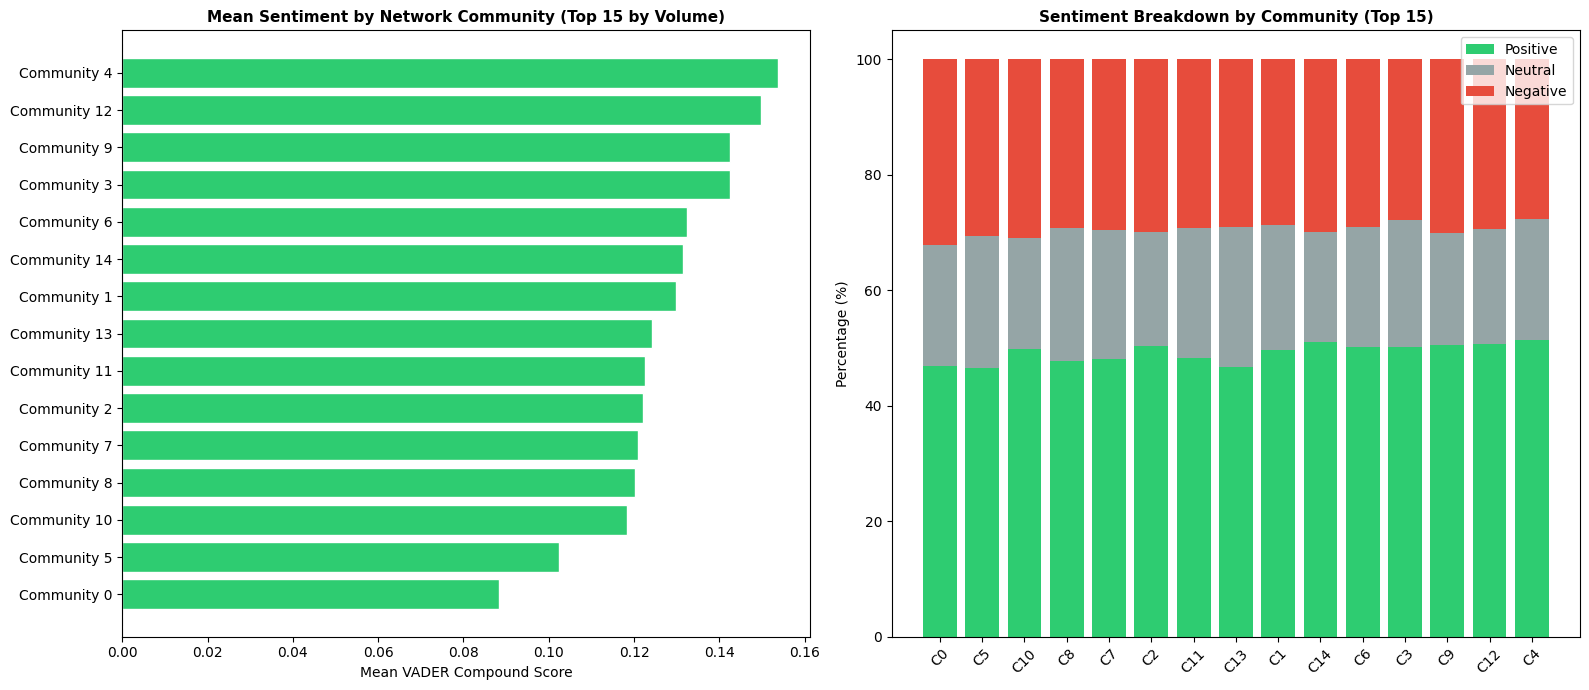

Saved: sentiment_by_community.png


In [21]:
top15 = community_sentiment.nlargest(15, 'n_comments').sort_values('mean_compound')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cols = ['#2ecc71' if v>=0 else '#e74c3c' for v in top15['mean_compound']]
axes[0].barh([f'Community {int(c)}' for c in top15['community']],
             top15['mean_compound'], color=cols, edgecolor='white')
axes[0].axvline(0, color='grey', linestyle='--', alpha=0.6)
axes[0].set_title('Mean Sentiment by Network Community (Top 15 by Volume)',
                  fontweight='bold', fontsize=11)
axes[0].set_xlabel('Mean VADER Compound Score')

x  = np.arange(len(top15))
pp = top15['pct_positive'].values
pn = top15['pct_neutral'].values
axes[1].bar(x, pp, label='Positive', color='#2ecc71')
axes[1].bar(x, pn, bottom=pp, label='Neutral',  color='#95a5a6')
axes[1].bar(x, top15['pct_negative'].values, bottom=pp+pn, label='Negative', color='#e74c3c')
axes[1].set_title('Sentiment Breakdown by Community (Top 15)', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'C{int(c)}' for c in top15['community']], rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sentiment_by_community.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sentiment_by_community.png')

## 8. Topic Distribution by Community (HD)

Heatmap: percentage of comments per topic for each of the top 15 communities.

In [22]:
top15_ids = [int(c) for c in top15['community'].tolist()]
tcd = matched[(matched['community'].isin(top15_ids)) & (matched['dominant_topic']>=0)].copy()

pivot = (
    tcd.groupby(['community','topic_label']).size()
    .reset_index(name='count')
    .pivot(index='community', columns='topic_label', values='count')
    .fillna(0)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.index = [f'Community {int(c)}' for c in pivot_pct.index]

print(pivot_pct.round(1).to_string())

topic_label   Battery Range & Performance  Charging Infrastructure  Environmental Benefits  Government Policy & Incentives  Grid & Energy Impact  Purchase Cost & Value  Real-world User Experience  Vehicle Models & Brands
Community 0                          11.5                     33.9                    13.1                             7.0                   7.9                   19.6                         2.4                      4.8
Community 1                          15.4                     30.0                    11.4                            10.3                   7.7                   19.8                         0.8                      4.6
Community 2                          17.2                     30.2                     9.1                            10.9                   8.3                   19.3                         0.7                      4.2
Community 3                          13.1                     32.9                     9.4                          

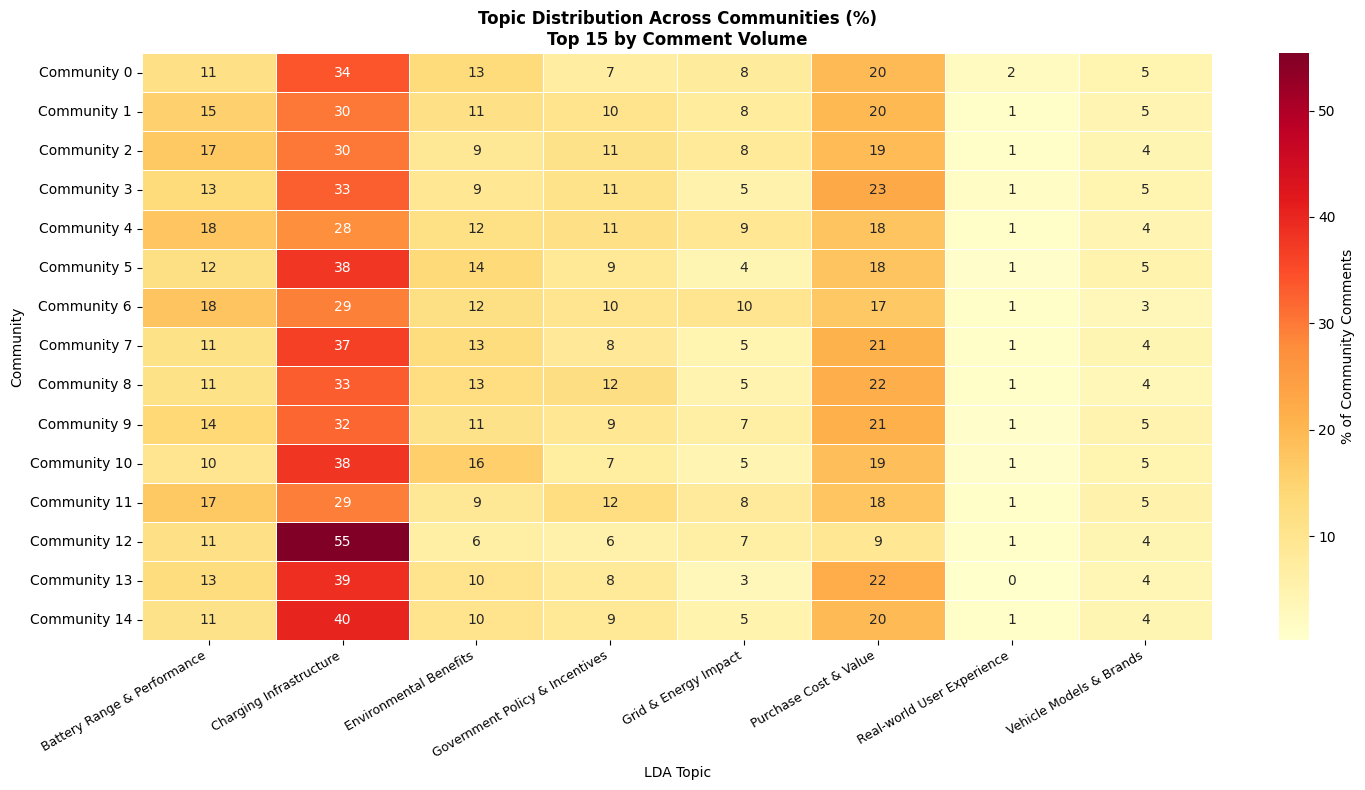

Saved: topic_by_community.png


In [23]:
fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(pivot_pct, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of Community Comments'})
ax.set_title('Topic Distribution Across Communities (%)\nTop 15 by Comment Volume',
             fontweight='bold', fontsize=12)
ax.set_xlabel('LDA Topic')
ax.set_ylabel('Community')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'topic_by_community.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: topic_by_community.png')

## 9. Save Outputs

In [24]:
print('Saving outputs...')

save_cols = [c for c in comments_df.columns if c != 'lda_tokens']
comments_df[save_cols].to_csv(
    os.path.join(PROCESSED_DIR, 'comments_with_sentiment.csv'), index=False)
print(f'Saved: comments_with_sentiment.csv ({len(comments_df):,} rows)')

community_sentiment.to_csv(
    os.path.join(PROCESSED_DIR, 'community_sentiment.csv'), index=False)
print(f'Saved: community_sentiment.csv ({len(community_sentiment)} communities)')

print()
print('ALL OUTPUTS SAVED.')
print('Figures:')
figs = ['sentiment_overview.png','sentiment_over_time.png','sentiment_by_subreddit.png',
        'lda_topics.png','topic_distribution.png','sentiment_by_topic.png',
        'sentiment_by_community.png','topic_by_community.png','lda_pyldavis.html']
for f in figs:
    print(f'  {f}')

Saving outputs...
Saved: comments_with_sentiment.csv (65,954 rows)
Saved: community_sentiment.csv (33 communities)

ALL OUTPUTS SAVED.
Figures:
  sentiment_overview.png
  sentiment_over_time.png
  sentiment_by_subreddit.png
  lda_topics.png
  topic_distribution.png
  sentiment_by_topic.png
  sentiment_by_community.png
  topic_by_community.png
  lda_pyldavis.html
